# Looking into the CLS token dynamics in the classifier

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm

import torch

import sys
sys.path.append('..')

from src.models.TTA_model import ClassifierWithTTA
from src.data.activity_data import ActivityGradientDataDict
from src.data.image_data import balanced_train_subsets

W1229 18:20:59.299000 9463 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


## Starting from where we left off in 1.2

We saw that, randomizing the CLS tokens in different layers, we find that the CLS tokens contain no CLS specific information. This leads to two immediate directions:

1. What happens if we make the classifier read-out less powerful? Where in the network does the CLS token representation start to arise?
2. Can we completely isolate the CLS token into the classification layers?


In [2]:
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

def model_accuracy(model, dataset):
    dl = torch.utils.data.DataLoader(dataset, batch_size=32)
    outputs = []
    
    for batch in tqdm(iter(dl)):
        images, labels = batch
        preds = model.forward(images.to('mps')).logits.argmax(1).cpu()
    
        outputs.append(preds.cpu() == labels)

    return torch.concat(outputs)

def randomize_layer_cls_token(model, layer_name, layer_ind, dataset, debug=False):
    def randomization_hook(module, input, output):
        if debug:
            print('in hook')
        copied_output = output.clone()
        batch, tokens, dims = copied_output.shape
        
        #ind_perm = torch.randperm(batch)
        copied_output[:, 0, :] = torch.randn(batch, dims)
        #copied_output[ind_perm, 0, :]
        
        return copied_output


    layer_registry = {'embedding': model.embedding.vit.encoder.layer,
                      'classifier': model.classifier.vit.encoder.layer
                     }        

    handle = layer_registry[layer_name][layer_ind].register_forward_hook(randomization_hook)
    outputs = model_accuracy(model, dataset)

    handle.remove()
    return outputs
    

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


#### Previous results:

In [3]:
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')
results = []

# baseline
cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

baseline = model_accuracy(cls_model, image_data).float().mean()
results.append({'layer': f'Baseline', 'accuracy': baseline.item()})

for layer_name, layer_num in [('embedding', 0), ('embedding', 11), ('classifier', 0), ('classifier', 1)]:
    cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
    cls_model = cls_model.to('mps')
    cls_model = cls_model.eval()
    
    accuracy = randomize_layer_cls_token(cls_model, layer_name, layer_num, image_data, debug=False).float().mean()

    results.append({'layer': f'{layer_name}_{layer_num}', 'accuracy': accuracy.item()})


results = pd.DataFrame(results)

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:01<00:00,  5.10it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:00<00:00,  5.17it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:01<00:00,  5.12it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:29<00:00,  3.50it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:14<00:00,  4.18it/s]


Text(0.5, 1.0, 'Accuracy after randomizing CLS tokens in a layer')

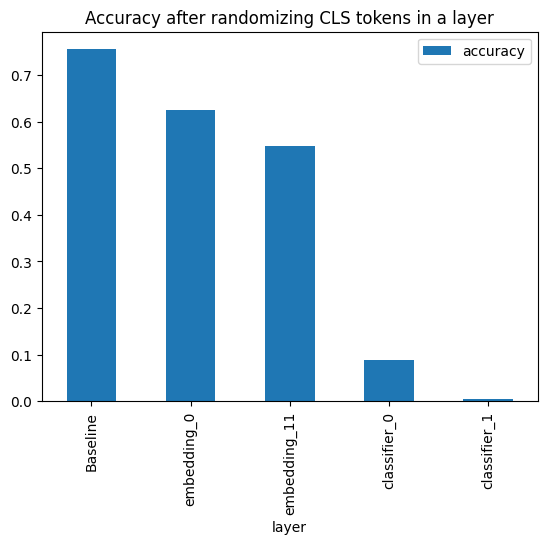

In [4]:
results.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy after randomizing CLS tokens in a layer')

This is identical to before. There _is_ some loss in the early layers, but the embedding 0 vs embedding 11 is much less than I would have expected.

I think that this degree of loss is consistent with 'the network wasn't trained for this'

### 'Pushing down' CLS token information:

I trained a model with a linear-only decoder. How does the CLS token causal effect look now?

In [5]:
embed_only_ckpt = '../experiments_base/2025-12-24(00:42:34)-no_classifier_transformer/checkpoints/full/best'

results_embed = []
layer_name  ='embedding'

# baseline
cls_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

baseline = model_accuracy(cls_model, image_data).float().mean()
results_embed.append({'layer': f'Baseline', 'accuracy': baseline.item()})

for layer_num in range(12):
    cls_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
    cls_model = cls_model.to('mps')
    cls_model = cls_model.eval()
    
    accuracy = randomize_layer_cls_token(cls_model, layer_name, layer_num, image_data, debug=False).float().mean()

    results_embed.append({'layer': f'{layer_name}_{layer_num}', 'accuracy': accuracy.item()})


results_embed = pd.DataFrame(results_embed)

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:03<00:00,  4.93it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  5.00it/s]


Loading weights from local directory


...

100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.81it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.77it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.74it/s]


Text(0.5, 1.0, 'Accuracy after randomizing CLS tokens in a layer')

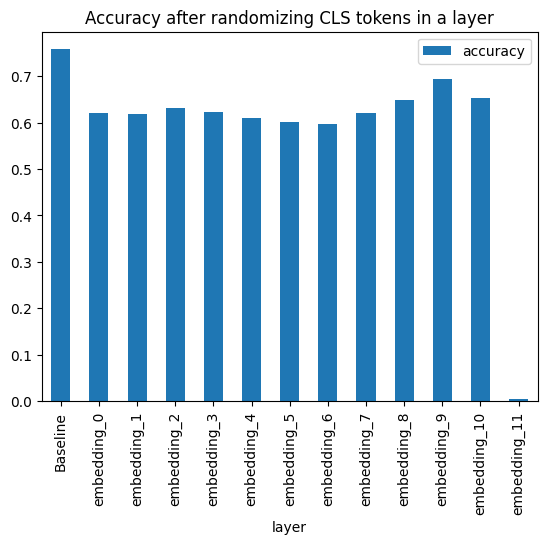

In [6]:
results_embed.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy after randomizing CLS tokens in a layer')

#### Huh. This is an odd result. 


1. The major accuracy destruction does not appear until the very last layer of the embedding.
2. There is a small but substantial impact ~12% (same as observed previously) of randomization in the very earliest layers.
3. Accuracy slowly decreases toward layer 6 before _increasing_ toward layer 9. Approximately an 8% increase.
   - pattern holds across replicates.

Leads to several questions:
1. What accounts for the early difference in performance from baseline?
    - lack of position encoding?
    - slightly earlier randomization than in the randomized model?
2. What accounts for the strange _increase_ midway through? Is this the point at which the CLS token -> image token information flow is 'complete'?
   - Is this where the effect of position embedding 'wears off'?
3. How is the accuracy still so good with only 1 embedding layer?
    - Seems to imply that the idea to 'push down' the CLS token dependence does not work.
    - The network prioritizes learning image token representations that are able to 'strongly separate' different classes in the final layer. Not on learning to slowly transform the image representation.


### The CLS token has little influence on outputs. Did it play a role earlier in the network?

Can we just use the lower half of the network in embedding mode, without any CLS tokens, and introduce the CLS tokens later in the classifier.

In [7]:
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
cls_model = ClassifierWithTTA.from_pretrained(base_ckpt)
cls_model = cls_model.to('mps')
cls_model = cls_model.eval()

Loading weights from local directory


In [8]:
def alt_forward(model, pixel_values, mode='alt_prepend'):
    """ Alternative model forward that does not use the CLS token until the classifier
    use_alt: turns on and off the alternative encoding path 
    """
    pixel_values = model.preprocess(pixel_values)

    if mode == 'alt_prepend':
        x = model.embedding.forward(pixel_values).logits

        # Only now we add the cls tokens.
        batch, n_tokens, n_dim = x.shape
        assert n_tokens == 196
    
        cls_tokens = torch.randn(batch, 1, n_dim, device=x.device)
        x = torch.concat([cls_tokens, x], dim=1)

    elif mode == 'alt_postpend':
        x = model.embedding.forward(pixel_values).logits

        # Only now we add the cls tokens.
        batch, n_tokens, n_dim = x.shape
        assert n_tokens == 196
    
        cls_tokens = torch.randn(batch, 1, n_dim, device=x.device)
        x = torch.concat([x, cls_tokens], dim=1)


    elif mode == 'base':
        x = model.embedding.embedding(pixel_values)

    elif mode == 'base_random':
        x = model.embedding.embedding(pixel_values)
        batch, tokens, dim = x.shape
        x[:, 0, :] = torch.randn(batch, dim)
        
    x = model.classifier.vit.encoder(x).last_hidden_state
    x = model.classifier.vit.layernorm(x)[:, 0, :]
    logits = model.classifier.classifier(x)

    return logits



In [11]:
dl = torch.utils.data.DataLoader(image_data, batch_size=32)
outs = {'base':[],
        'base_random': [],
        'alt_prepend': [],
       }


for batch in tqdm(iter(dl)):
    images, labels = batch

    for mode in outs.keys():
        preds = alt_forward(cls_model, images.to('mps'), mode)
        outs[mode].append( (preds.argmax(1).cpu() == labels))



100%|█████████████████████████████████████████| 313/313 [03:43<00:00,  1.40it/s]


Text(0.5, 1.0, 'Using embedding model with no CLS tokens.')

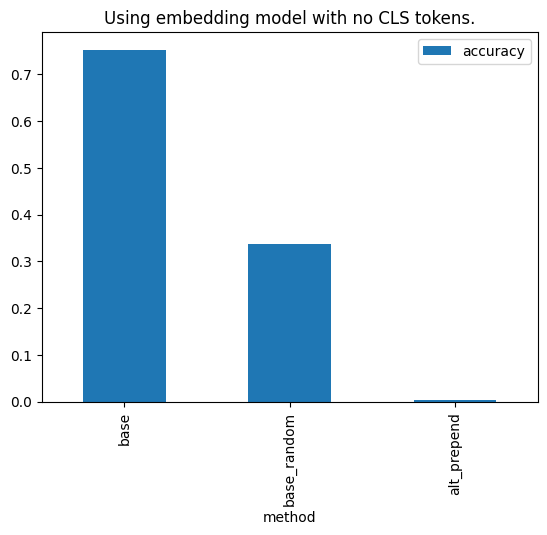

In [16]:
results_embed_mode = [{'method': key, 'accuracy': torch.concat(value).float().mean().item()} for key, value in outs.items()]
results_embed_mode = pd.DataFrame(results_embed_mode)
results_embed_mode.plot.bar(x='method', y='accuracy')
plt.title('Using embedding model with no CLS tokens.')

`base` is a negative control on the code. `alt_prepend` is experimental. `base_random` was supposed to be another negative control.

1. I'm surprised to see this much effect in the `base_random` case. However, I don't think this is a sign of a bug in the code: `base_random` randomizes at the step between the embedding and classifier, an produces outputs that are midway between randomizing each of these.

2. The prepend result (in compairison to the base random result) is a strong rejection of the idea that introducing tokens at this point is equivalent to randomizing the cls tokens at the same point.

I suspect that this is because:
- _the network wasn't trained for this_
- base mode puts the CLS token at the 0 index in the sequence, and the image and (1, n+1), while this mode does image processing in the (0, n) positions

This addition to the loss seen in `base_random` from token randomization.

#### There's a pattern here

The _last layer_ of the embedding seems to be responsible for mapping the CLS token to the 'decoding space'


### Another check:

This base randomization result seems at odds with our previous results in notebook 1.2 swapping cls tokens and activity, and finding that outputs depend almost entirely on the activity.

__Answer:__ Everything replicates properly.

In [2]:
from src.models.TTA_model import ClassifierWithTTA
from src.data.image_data import balanced_train_subsets
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')
activity_data_test = torch.load('../activity_analysis/2025-12-22_01_44_59_data_gen/activity_data_test.pt')
print((activity_data_test['gts'] == image_data[:][1]).all())

model_cls = ClassifierWithTTA.from_pretrained('../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best')
model_cls = model_cls.to('mps')
model_cls = model_cls.eval()

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


tensor(True)
Loading weights from local directory


#### What is the hook actually measuring?

The previous activity used hooks to record. Is this the same as the model outputs?

Ans: yes.

In [3]:
all_tokens = []
def recording_hook(module, input, output):
    all_tokens.append(output.detach().clone().cpu())

handle = model_cls.embedding.vit.layernorm.register_forward_hook(recording_hook)

In [4]:
processed = model_cls.preprocess(image_data[2:4][0].to('mps'))
activity = model_cls.embedding.embedding(processed)

In [5]:
(activity.cpu() == all_tokens[0]).all()

tensor(True)

#### Repeating the cls vs image token experiment

Slightly rewritten

In [6]:
def decode_token(token, model, base_activity):
    x = base_activity.clone()
    x[0,0,:] = token.to('mps')
    
    x = model.classifier.vit.encoder(x).last_hidden_state
    x = model.classifier.vit.layernorm(x)[:, 0, :]
    logits = model.classifier.classifier(x)
    return logits.argmax(1)

def sample_pairs(model, image_data, activity_data, linked=False, normal_tokens=False):
    results = {}
    i = torch.randint(10000, (1,))[0]
    if linked:
        j = i
    else:
        j = torch.randint(10000, (1,))[0]

    results['image_gt'] = image_data[i:i+1][1].item()
    image = image_data[i:i+1][0]

    processed = model.preprocess(image.to('mps'))
    embedding = model.embedding.embedding(processed)

    results['cls_token_gt'] = activity_data['gts'][j].item()
    cls_token = activity_data['activity'][j][torch.randint(50, (1,))]

    if normal_tokens:
        cls_token = torch.randn(1,1, embedding.shape[2])

    results['joint_output'] = decode_token(cls_token, model, embedding).item()

    return results

In [4]:
linked_results = []
for i in tqdm(range(5000)):
    linked_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=True))

linked_results = pd.DataFrame(linked_results)

100%|███████████████████████████████████████| 5000/5000 [01:00<00:00, 83.06it/s]


In [5]:
random_results = []
for i in tqdm(range(10000)):
    random_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=False))

random_results = pd.DataFrame(random_results)

100%|█████████████████████████████████████| 10000/10000 [02:00<00:00, 82.75it/s]


Checks:

In [6]:
(linked_results['cls_token_gt'] == linked_results['image_gt']).all()

np.True_

In [7]:
(linked_results['image_gt'] == linked_results['joint_output']).mean()

np.float64(0.7512)

Linked control: gts are aligned, 75% output accuracy

In [8]:
(random_results['cls_token_gt'] == random_results['image_gt']).mean()

np.float64(0.0052)

In [9]:
(random_results['cls_token_gt'] == random_results['joint_output']).mean()

np.float64(0.009)

In [10]:
(random_results['image_gt'] == random_results['joint_output']).mean()

np.float64(0.733)

The reproduces the result in 1.2: Almost all of the output is determined by the image tokens, rather than the cls token. Important control: the cls and image tokens are almost never from the same underlying class.

What if we compare to normal cls tokens again?

In [11]:
normal_results = []
for i in tqdm(range(5000)):
    normal_results.append(sample_pairs(model_cls, image_data, activity_data_test, linked=False, 
                                      normal_tokens=True))

normal_results = pd.DataFrame(normal_results)

100%|███████████████████████████████████████| 5000/5000 [01:00<00:00, 82.03it/s]


In [12]:
(normal_results['image_gt'] == normal_results['joint_output']).mean()

np.float64(0.3434)

Yes. Reproduces the result that I saw above.



#### Conclusion:

Everything replicates. Outputs _are_ dominated by image token identity. Sampling from a normal distribution of cls tokens _does_ send the accuracy to 30%

### Interpreting this:

The results above:
- outputs are dominated by image token identity
- normal distribution of cls tokens sends the accuracy to 30%
- sampling instead from the recorded cls_token activity distribution gives 73% accuracy, almost as good as the paired.

This looks to me like _exactly_ what I thought I would see in Notebook 1.3, but specific to the classifier: there is a specific distribution of tokens that works well as inputs to the classifier (I can probably get back up to 75% by training with this sampling scheme). Deviating from this kills classifier performance.

This, then re-raises the question of the fixed-point distribution, at the scale of the classifier. Note that this is _conditional_ on the encoder.

This is saying exactly the thing that we're looking for: the classifier's performance is contingent on the _distribution_ of cls tokens, but not on the individual cls tokens. In other words, that distribution can be used to test classifier performance. (HOWEVER, individual datapoint distributions will not be the same as multi-point distributions, so that adds a wrinkle)


### How does shuffled activity compare to randomized?

These measurements test the balance of two factors:
1. How much information is in the cls_token?
2. How much does the over-all location of tokens matter?

(shuffle acc > normal acc) =>  the location is important, but not the value

(normal acc > shuffle acc) =>  the value more important than the location

I expect that shuffle will generally outperform normal resampling because the tokens are 'about right'. If the reverse occurs, this is a sign that information in the CLS token is _being used_ heavily. However, this is not a very sensitive metric, because the normal resampling is a very blunt intervention.

In [2]:
from src.analysis.layer_randomization import randomize_cls_token
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


#### Model with transformer classifier

In [3]:
# baseline
base_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'
readout_model = ClassifierWithTTA.from_pretrained(base_ckpt)
readout_model = readout_model.to('mps')
readout_model = readout_model.eval()

embedding_layers = 'embedding.vit.encoder.layer.{i}'
classifier_layers = 'classifier.vit.encoder.layer.{i}'

Loading weights from local directory


In [4]:
readout_accuracy = []
for embedding_ind in range(12):
    layer_name = embedding_layers.format(i=embedding_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
        readout_accuracy.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })

for classification_ind in range(2):
    layer_name = classifier_layers.format(i=classification_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
        readout_accuracy.append({'module': 'classifier', 'layer': classification_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })


readout_accuracy = pd.DataFrame(readout_accuracy)

100%|███████████████████████████████████████████| 79/79 [01:05<00:00,  1.20it/s]


In [6]:
readout_accuracy['layer_name'] = readout_accuracy['module'] + readout_accuracy['layer'].astype(str)

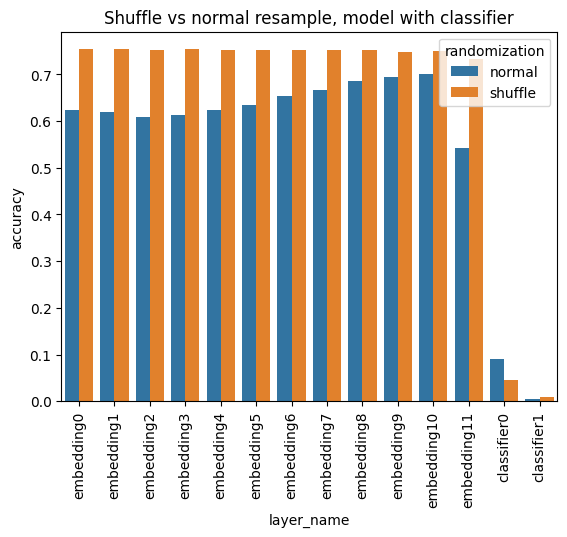

In [16]:
sns.barplot(readout_accuracy, x='layer_name', y='accuracy', hue='randomization')
_=plt.xticks( rotation=90)
_=plt.title('Shuffle vs normal resample, model with classifier')

Notes:
1. Shuffle accuracy is close to baseline throughout the embedding. Slight decrease at layer 11.
2. Shuffle accuracy collapses in the classifier. The first classifier layer shows evidence for class-specific information: more effect than 'pure' randomization.
3. Fulctuating normal distribution accuracy through the network: must relate to how 'similar' the cls tokens at these points are to normal samples
    - this is similar to the effect that we saw in the pure embedding network (above and below)
    - it again increases toward layer 10, before falling suddenly at layer 11.


#### Double check behavior of embedding outputs

In [27]:
layer_name = 'embedding.vit.layernorm'
check = []
for randomization_mode in ['normal', 'shuffle']:
    acc = randomize_cls_token(readout_model, layer_name, image_data, randomization_mode=randomization_mode)
    check.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                    'randomization': randomization_mode
                   })

check = pd.DataFrame(check)

100%|███████████████████████████████████████████| 79/79 [00:57<00:00,  1.37it/s]


<Axes: xlabel='randomization', ylabel='accuracy'>

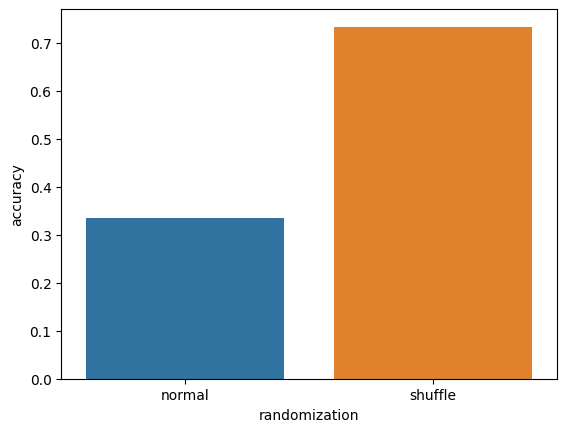

In [29]:
sns.barplot(check, x='randomization', y='accuracy', hue='randomization')

Slightly lower shuffle outputs, as with the last transformer layer of the embedding. Significantly lower normal distribution outputs, probably a simple result of missing layer norm.

#### Model with only embedding

In [17]:
# baseline
embed_only_ckpt = '../experiments_base/2025-12-24(00:42:34)-no_classifier_transformer/checkpoints/full/best'

embed_only_model = ClassifierWithTTA.from_pretrained(embed_only_ckpt)
embed_only_model = embed_only_model.to('mps')
embed_only_model = embed_only_model.eval()

embedding_layers = 'embedding.vit.encoder.layer.{i}'

embed_only_accuracy = []
for embedding_ind in range(12):
    layer_name = embedding_layers.format(i=embedding_ind)

    for randomization_mode in ['normal', 'shuffle']:
        acc = randomize_cls_token(embed_only_model, layer_name, image_data, randomization_mode=randomization_mode)
        embed_only_accuracy.append({'module': 'embedding', 'layer': embedding_ind, 'accuracy': acc,
                        'randomization': randomization_mode
                       })

embed_only_accuracy = pd.DataFrame(embed_only_accuracy)

Loading weights from local directory


100%|███████████████████████████████████████████| 79/79 [00:55<00:00,  1.43it/s]


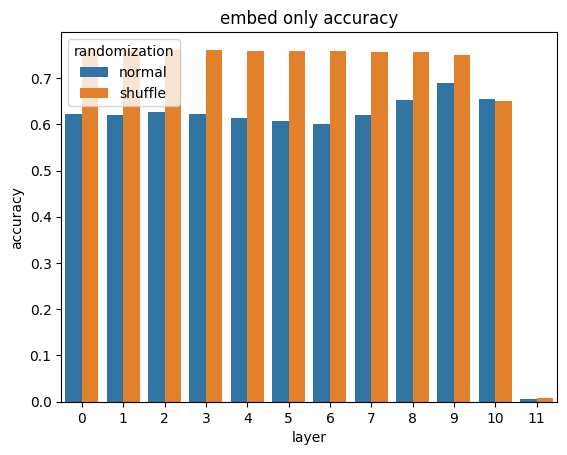

In [18]:
sns.barplot(embed_only_accuracy, x='layer', y='accuracy', hue='randomization')
_=plt.title('embed only accuracy')

A couple of things worth noting:
1. Shuffle accuracy matches baseline across the lower layers
   - there is a (moderate) impact of having the wrong token distribution here.
2. Shuffle accuracy is decreasing: no increase toward the end of the embedding
    - the increase when randomizing by normal sampling is likely due to some similarity between the gt embedding at that point and the normal distribution samples.
3. The shuffled embedding _does_ see a small decrease in layer 10.
    - this is the only point where normal sampling is (marginally) better than shuffled.
4. Final fall-off at layer 11: back to random performance.
    - in some ways, this is a control on the results: the shuffling does matter somewhere

#### Indeed, shuffling has almost no impact on the output distribution until the last stages of the network.